In [ ]:
import phik
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

In [65]:
df = pd.read_csv("./data/adult.csv")

# Distribution of target

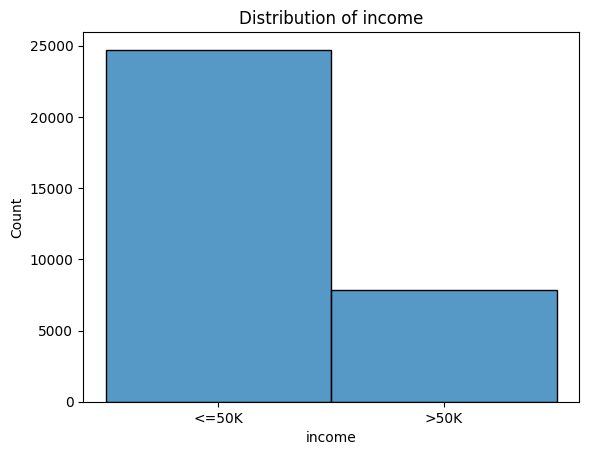

In [66]:
plt.title("Distribution of income")
sns.histplot(x="income", data=df);

# Distributions of predictors

In [67]:
predictors = df.columns.drop(["income", "education.num"]).to_list()

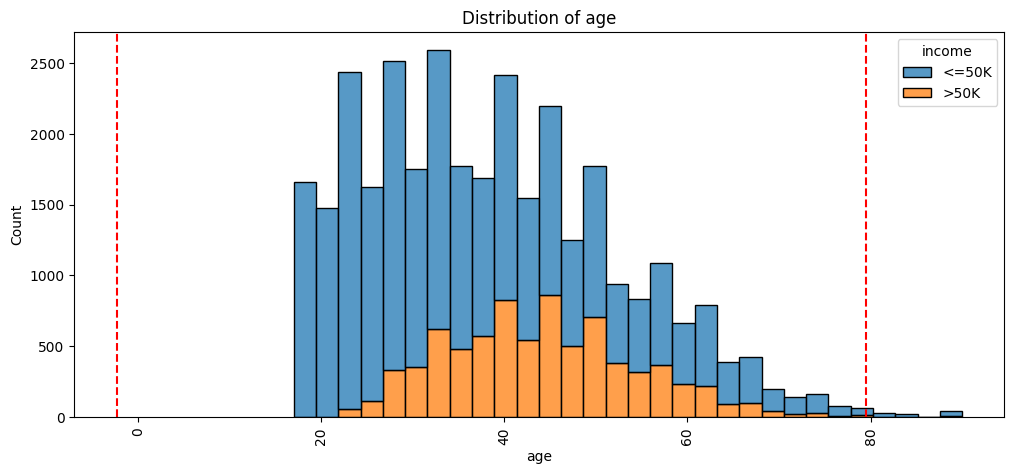

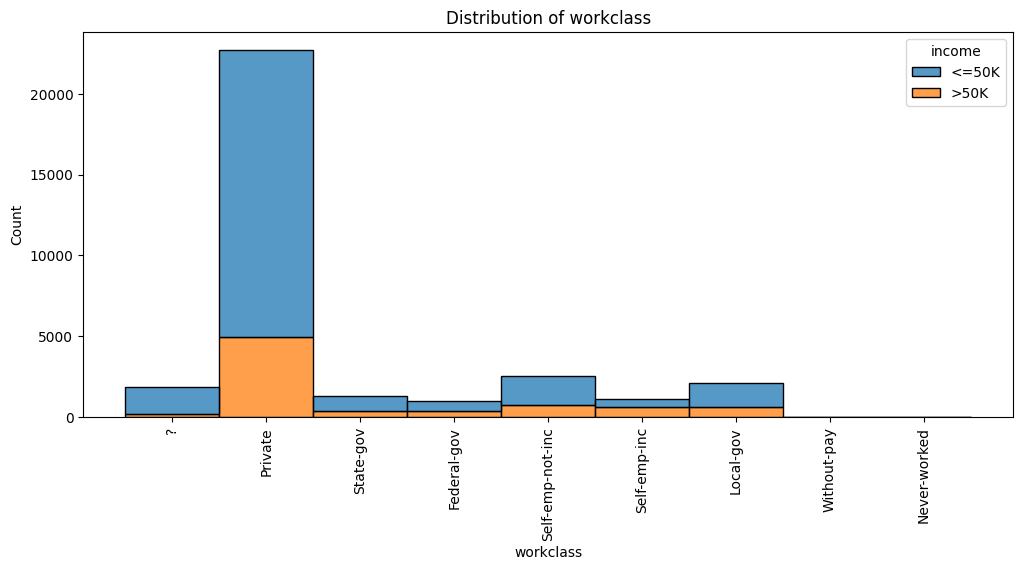

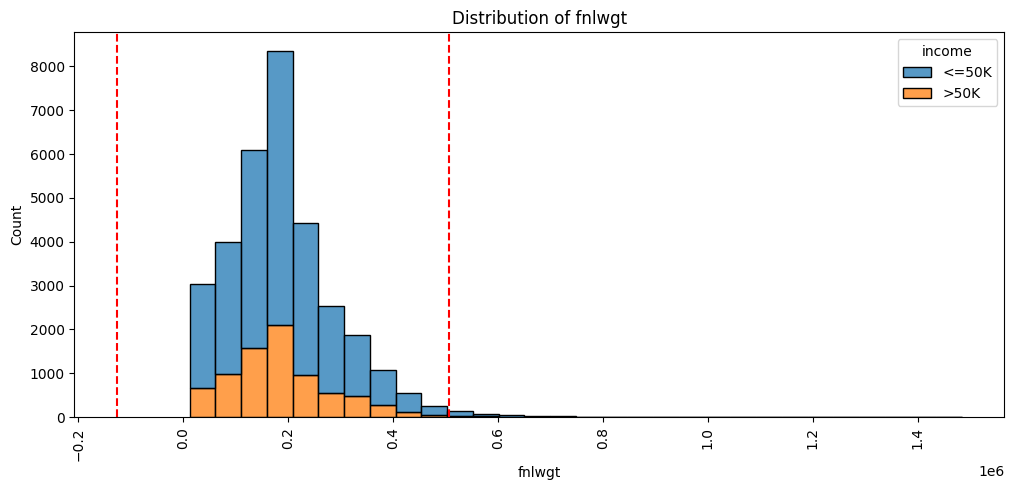

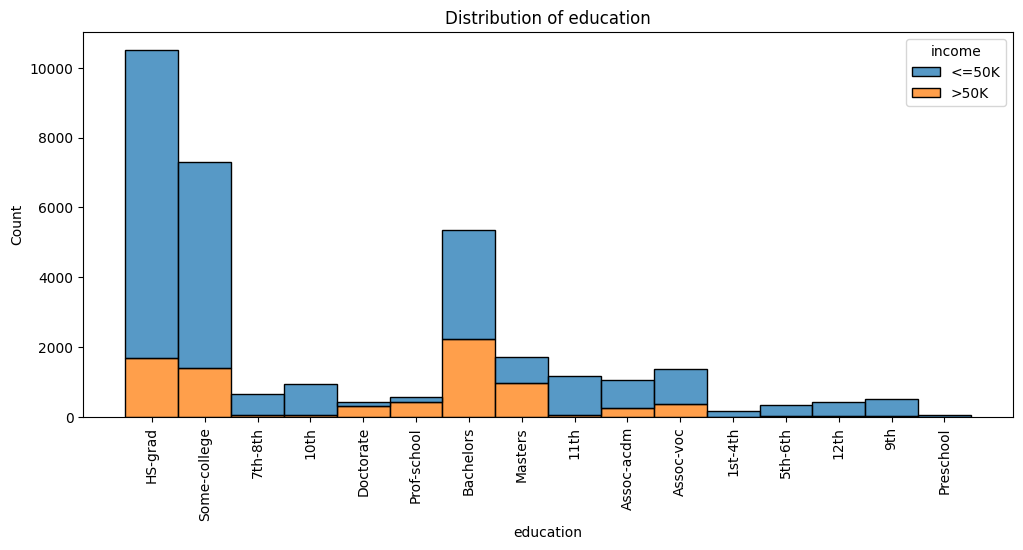

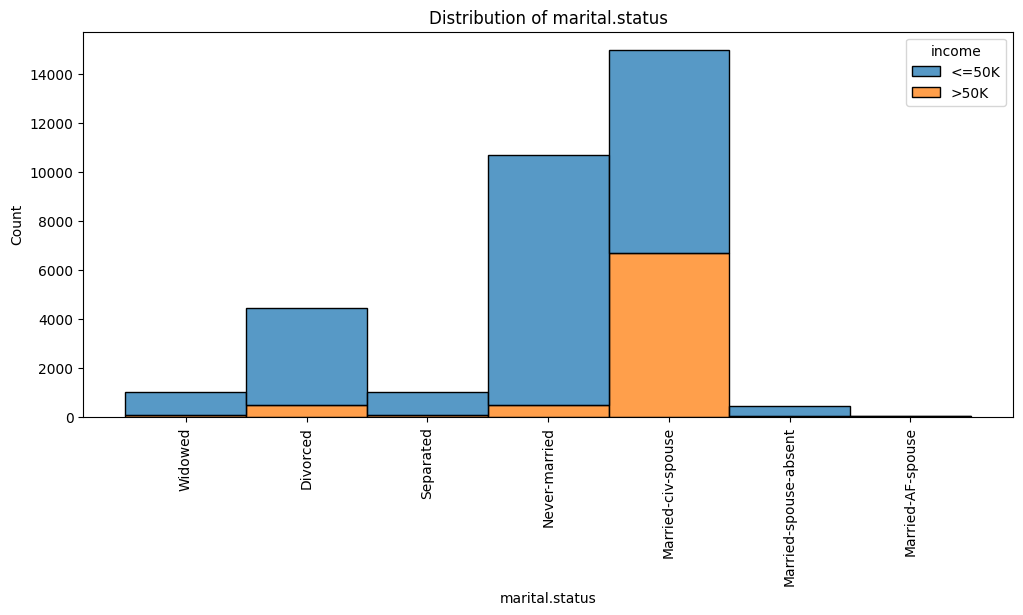

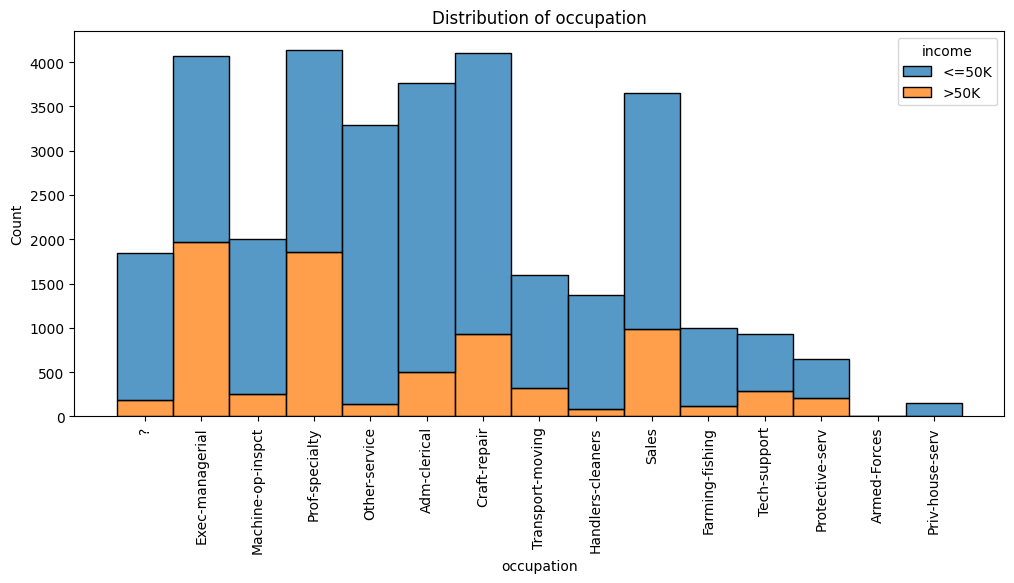

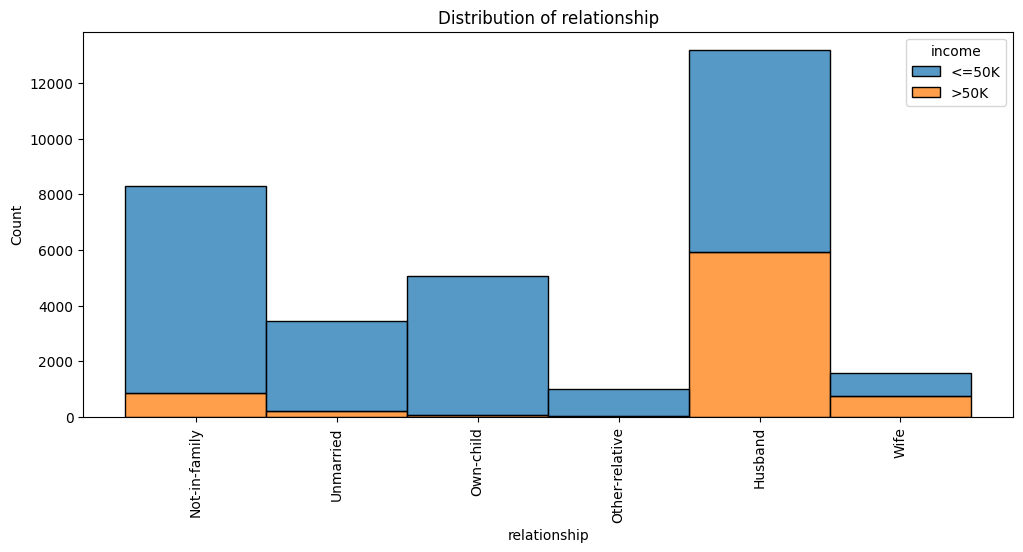

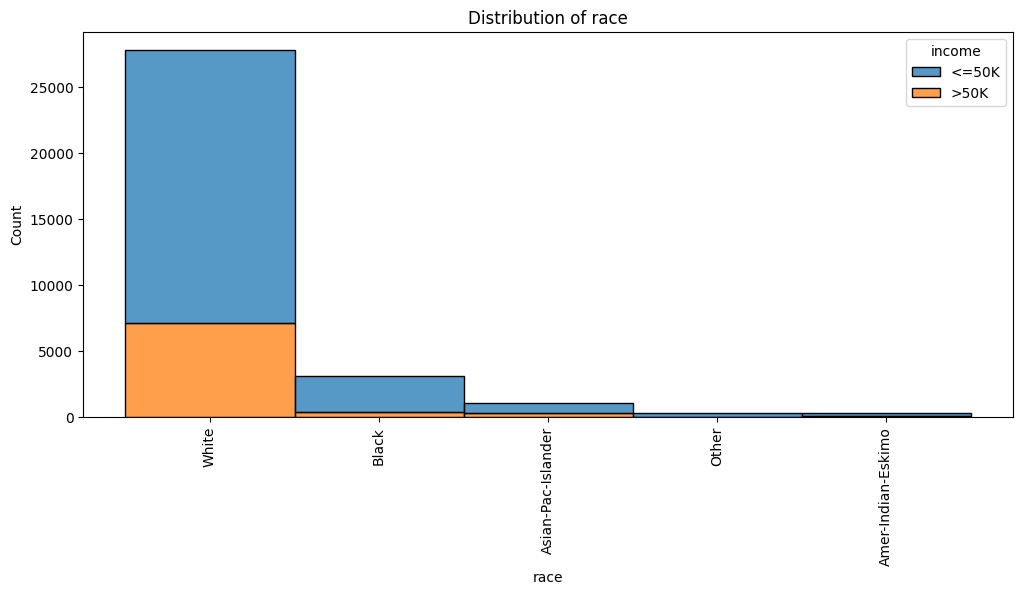

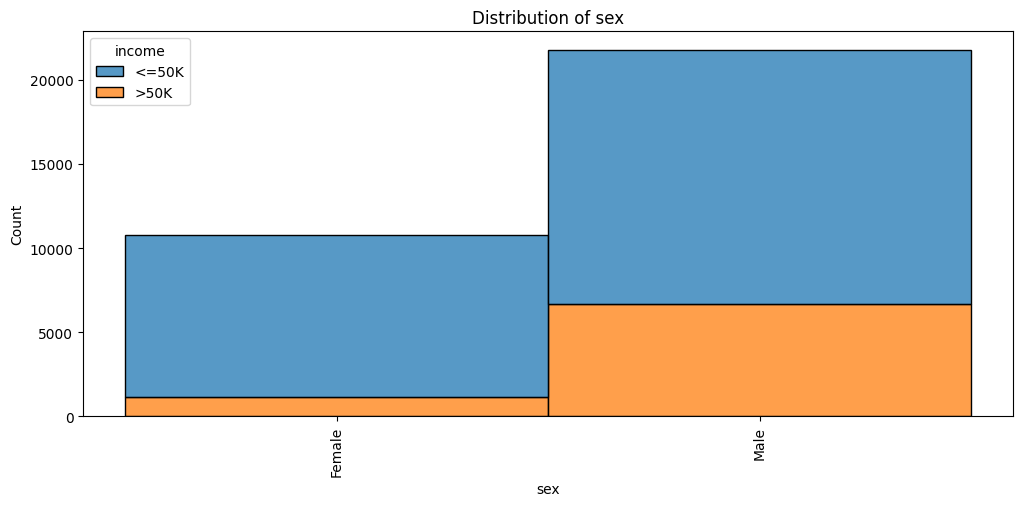

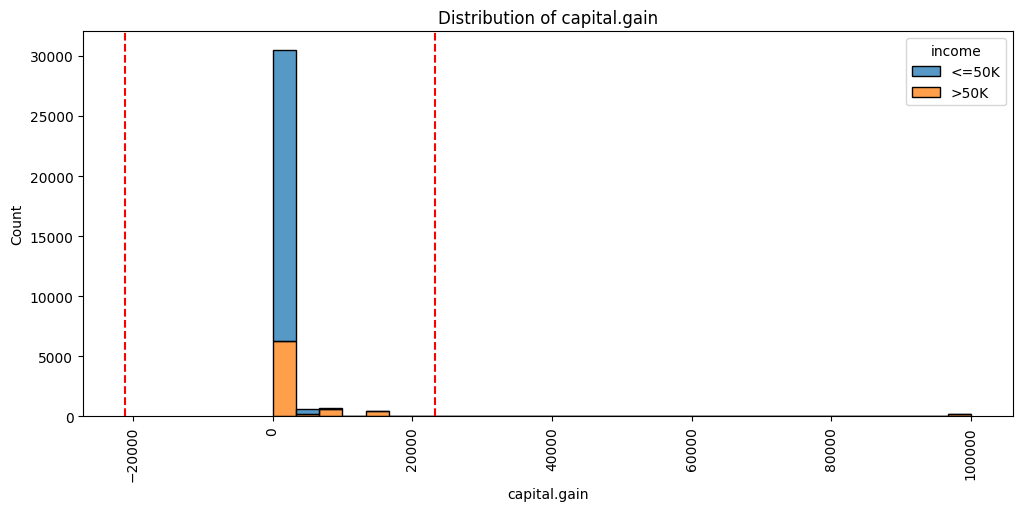

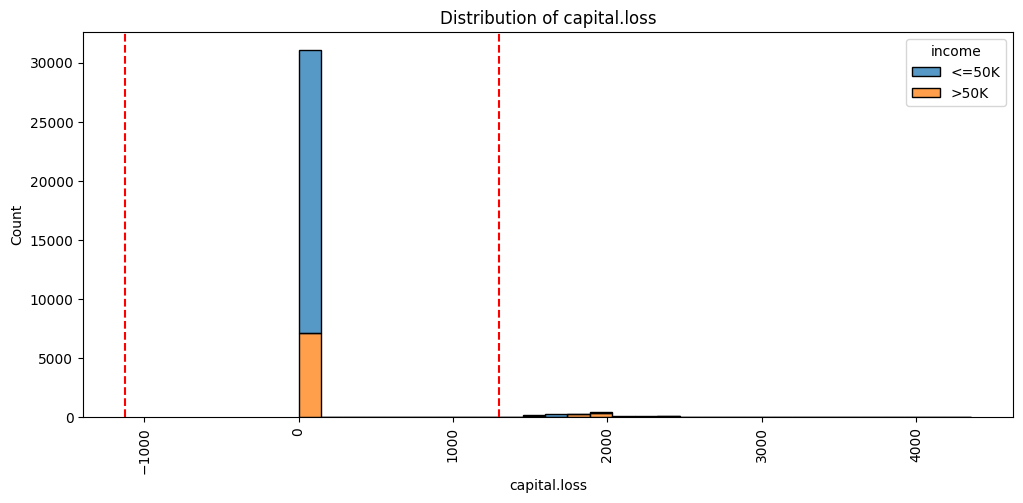

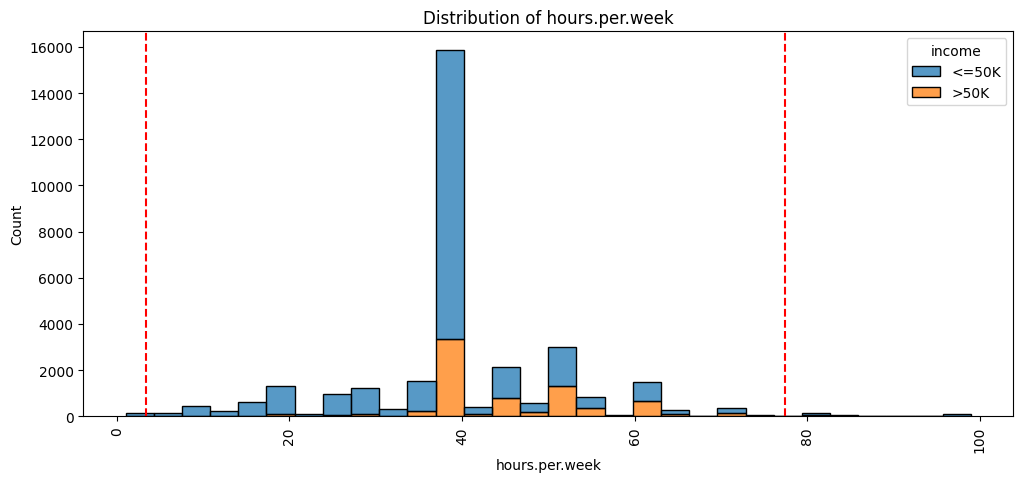

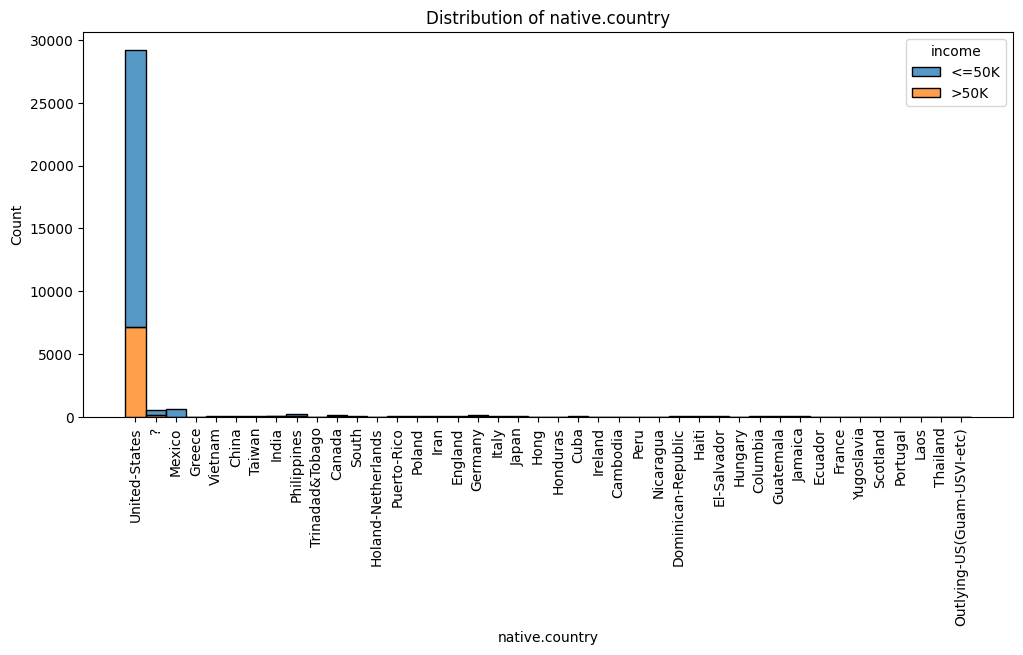

In [68]:
for pred in predictors:
    plt.figure(figsize=(12, 5))

    sns.histplot(x=pred, data=df, hue="income", multiple="stack", bins=30)
    
    plt.title(f"Distribution of {pred}")
    plt.tick_params(axis='x', rotation=90)

    if pd.api.types.is_numeric_dtype(df[pred]):
        mean = df[pred].mean()
        std = df[pred].std()
        for z in [-3, 3]: plt.axvline(mean + z*std, linestyle='--', color="red")

    plt.show();

# Interpretable pair-plots of predictors

In [92]:
def pairplot(df: pd.DataFrame, x: str, y: str):
    df = df.copy()

    plt.figure(figsize=(12, 5))

    is_categorical_x = isinstance(df[x].dtype, pd.StringDtype)
    is_categorical_y = isinstance(df[y].dtype, pd.StringDtype)

    if not is_categorical_x and is_categorical_y:
        x, y = y, x
        is_categorical_x, is_categorical_y = is_categorical_y, is_categorical_x

    if not is_categorical_x and not is_categorical_y:
        sns.scatterplot(data=df, x=x, y=y, hue="income")
        plt.title(f"Pair-plot of {x} and {y} (scatter)")

    if is_categorical_x and not is_categorical_y:
        sns.violinplot(data=df, x=x, y=y, hue="income", inner=None)
        plt.xticks(rotation=90)
        plt.title(f"Pair-plot of {x} and {y} (violin)")
    
    if is_categorical_x and is_categorical_y:
        df["income.num"] = (df["income"] == ">50K").astype(int)

        pivot = df.pivot_table(index=x, columns=y, values="income.num", aggfunc="mean").fillna(0)
        counts = pd.crosstab(df[x], df[y])

        sns.heatmap(pivot, cmap="coolwarm", linewidths=0.5, annot=counts, fmt="d")
        plt.xticks(rotation=90)
        plt.title(f"Pair-plot of {x} and {y} (heatmap of high-income ratios)")
    
    plt.show()

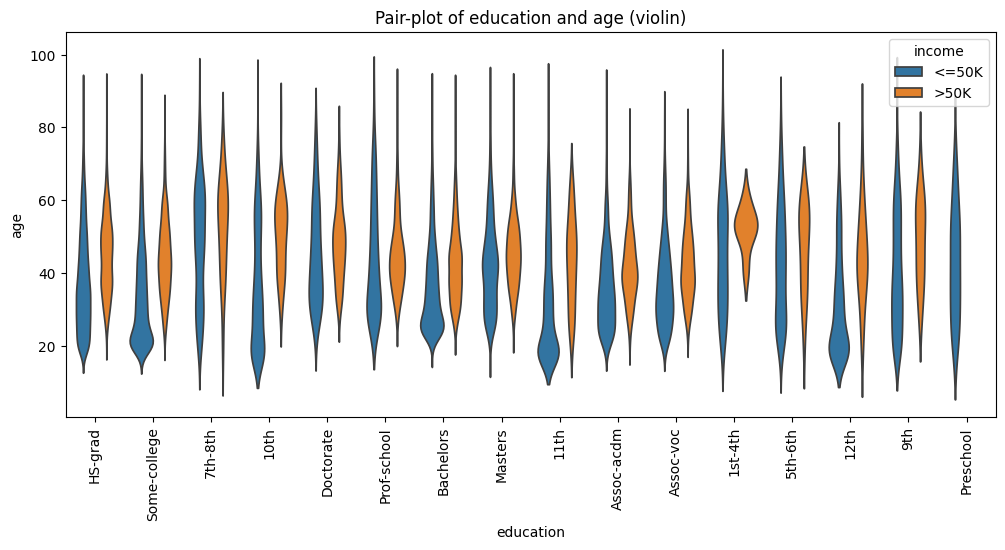

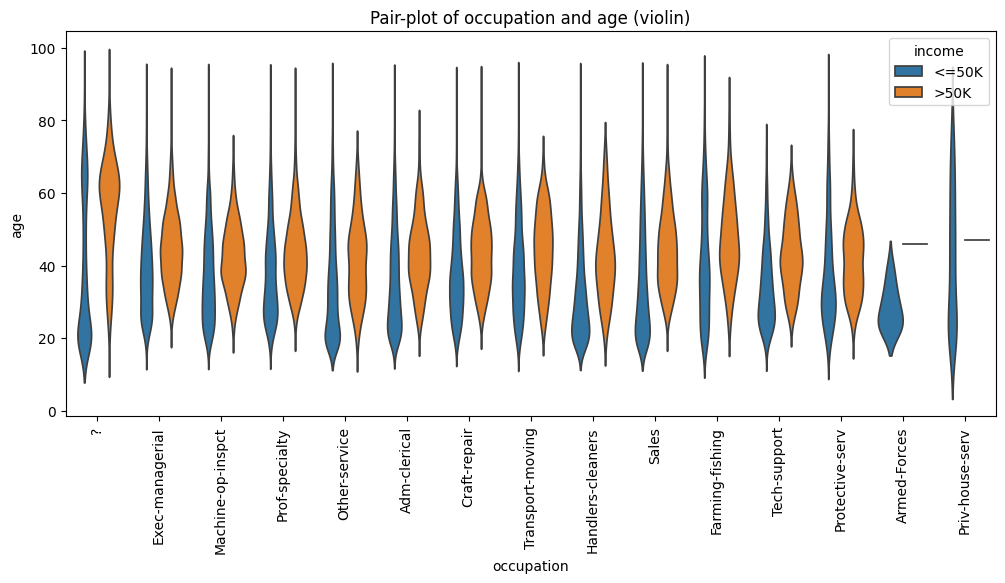

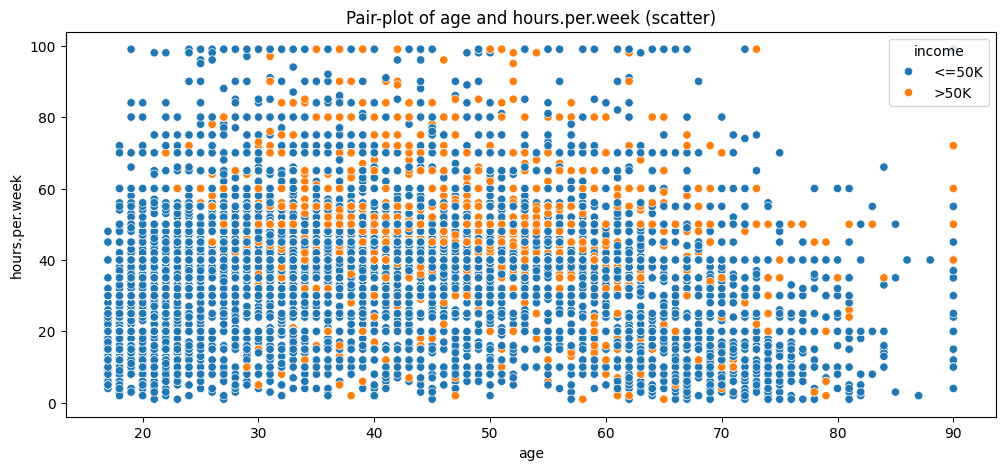

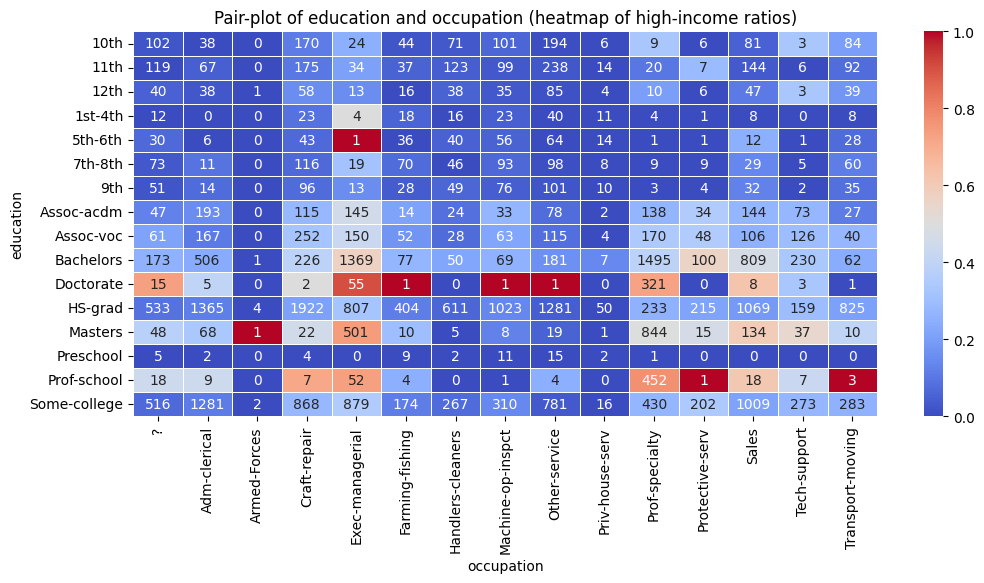

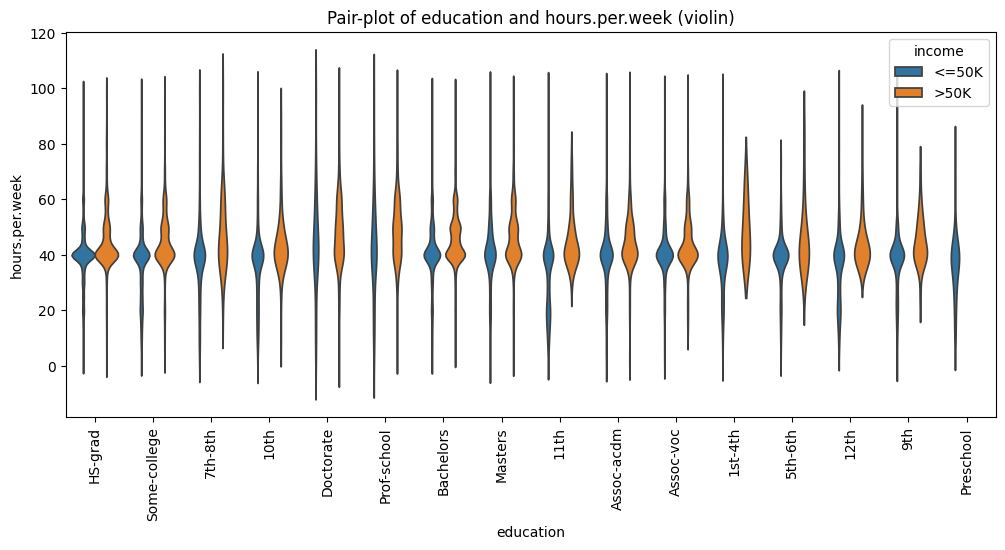

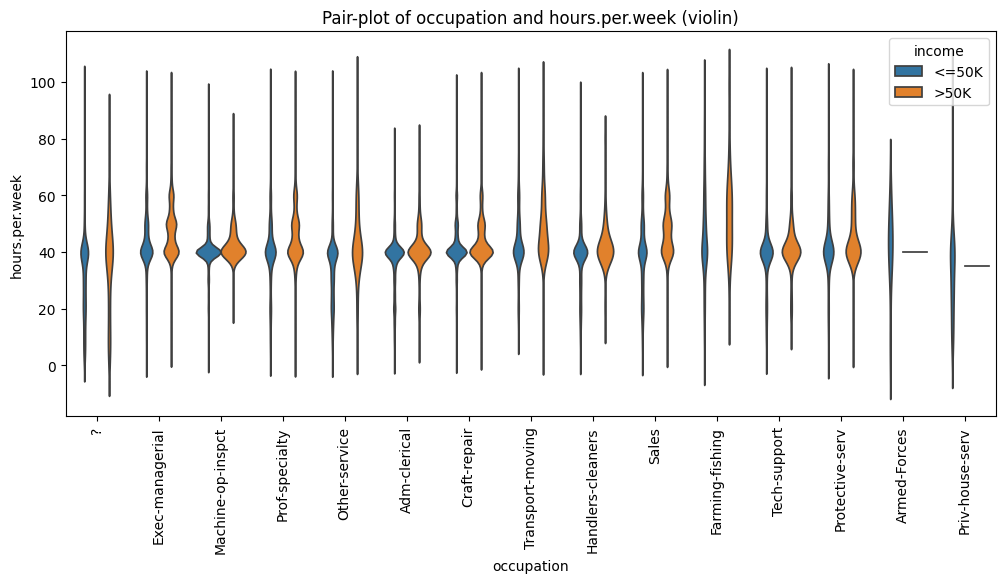

In [93]:
pair_cols = ["age", "education", "occupation", "hours.per.week"]

for x, y in itertools.combinations(pair_cols, 2):
    pairplot(df, x, y)

# Phik Correlation Matrix

interval columns not set, guessing: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']


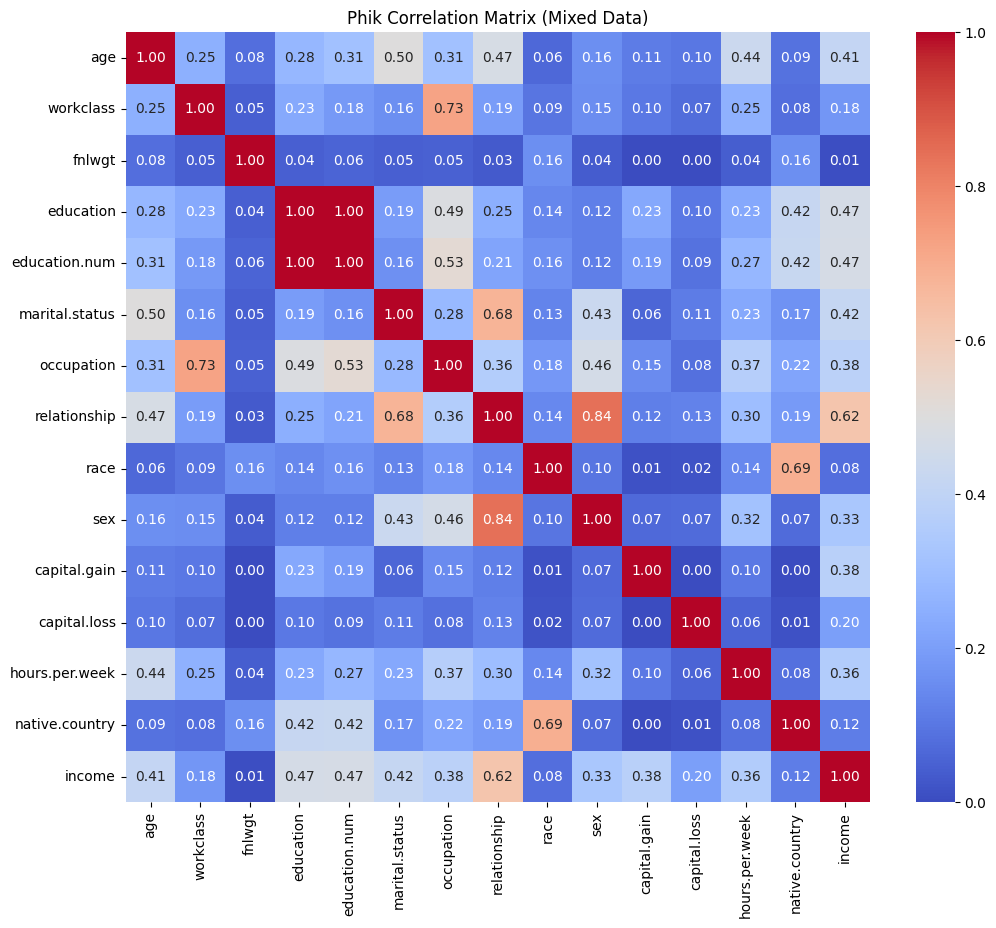

In [83]:
phik_corr = df.phik_matrix()

plt.figure(figsize=(12, 10))
sns.heatmap(phik_corr, cmap="coolwarm", vmin=0, vmax=1, annot=phik_corr, fmt=".2f")
plt.title("Phik Correlation Matrix (Mixed Data)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()